# Mall Customers Clustering

This notebook clusters mall customers by **Annual Income (k$)** and **Spending Score (1-100)** using K-Means, explores the optimal number of clusters (Elbow method), visualizes clusters, and provides a DBSCAN example as a bonus.

**Data set Available:** https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python?resource=download

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# display settings
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (8,6)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1) Load dataset



In [ ]:
csv_path = '/content/drive/MyDrive/Colab Notebooks/data/Mall_Customers.csv'
df = pd.read_csv(csv_path)
print('Dataset shape:', df.shape)
df.head()

Dataset shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 2) Select features (Annual Income & Spending Score)

In [ ]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].copy()
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


## 3) Scale features
K-Means is distance-based, so scaling is recommended.

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[:5]

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992]])

## 4) Elbow method (inertia) and silhouette scores
We run K-Means for k from 1..10 and plot inertia. We'll also compute silhouette for k>=2.

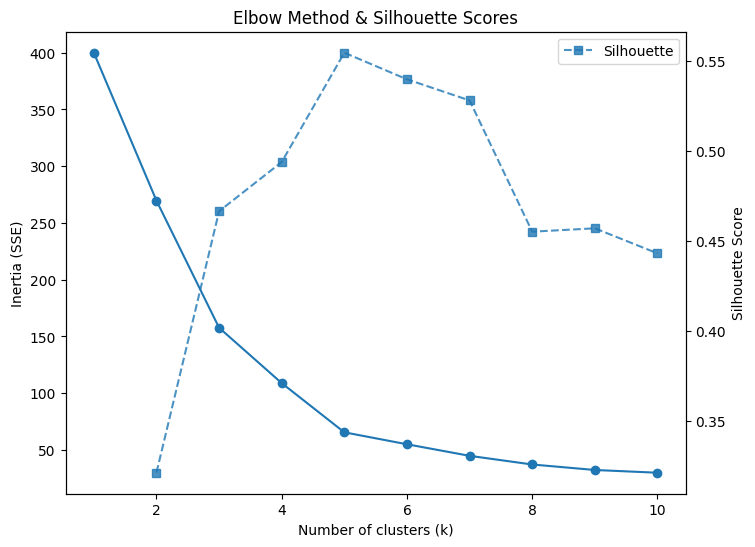

Inertia: [399.99999999999994, 269.69101219276405, 157.70400815035939, 108.92131661364358, 65.56840815571681, 55.057348270385965, 44.86475569922555, 37.22818767758587, 32.39226763033118, 29.981897788243703]
Silhouette scores: [nan, np.float64(0.3212707813918878), np.float64(0.46658474419000145), np.float64(0.4939069237513199), np.float64(0.5546571631111091), np.float64(0.5398800926790663), np.float64(0.5281492781108291), np.float64(0.4552147906587443), np.float64(0.4570853966942764), np.float64(0.4431713026508046)]


In [ ]:
inertia = []
sil_scores = []
K = range(1,11)
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)
    if k > 1:
        labels = km.labels_
        sil_scores.append(silhouette_score(X_scaled, labels))
    else:
        sil_scores.append(np.nan)

fig, ax1 = plt.subplots()
ax1.plot(K, inertia, marker='o')
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Inertia (SSE)')
ax1.set_title('Elbow Method & Silhouette Scores')

ax2 = ax1.twinx()
ax2.plot(K, sil_scores, marker='s', linestyle='--', alpha=0.8, label='Silhouette')
ax2.set_ylabel('Silhouette Score')
ax2.legend(loc='upper right')
plt.show()

print('Inertia:', inertia)
print('Silhouette scores:', sil_scores)

## 5) Apply K-Means
Set `k` based on the elbow + silhouette. Change `k` below if you want to try different values.

In [ ]:
# Choose k (update if needed after inspecting the plot)
k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)
centers_scaled = kmeans.cluster_centers_
centers = scaler.inverse_transform(centers_scaled)

print(df['KMeans_Cluster'].value_counts())

# Cluster summary
cluster_summary = df.groupby('KMeans_Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()
cluster_summary['Size'] = df.groupby('KMeans_Cluster').size()
cluster_summary = cluster_summary[['Size', 'Annual Income (k$)', 'Spending Score (1-100)']]
cluster_summary

KMeans_Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64


,Size,Annual Income (k$),Spending Score (1-100)
KMeans_Cluster,,,
0,81,55.296296,49.518519
1,39,86.538462,82.128205
2,22,25.727273,79.363636
3,35,88.200000,17.114286
4,23,26.304348,20.913043


## 6) Visualize clusters (2D scatter)
Centroids are marked with an 'X'.

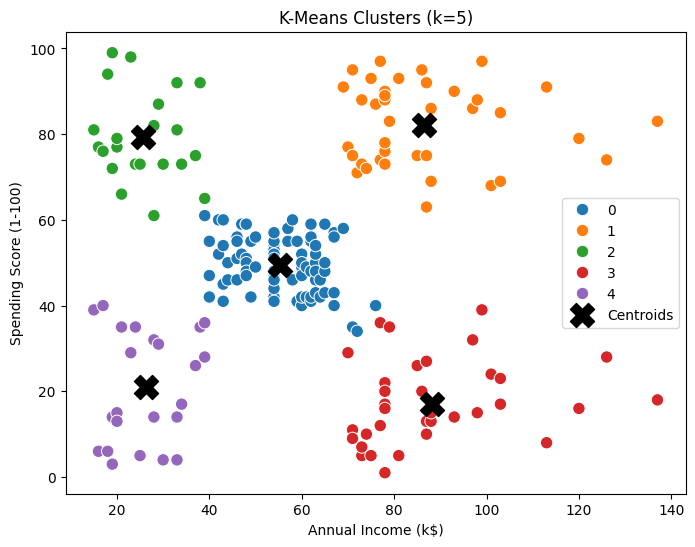

In [ ]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(
    x='Annual Income (k$)', y='Spending Score (1-100)',
    hue='KMeans_Cluster', palette='tab10', data=df, s=80, legend='full'
)
plt.scatter(centers[:,0], centers[:,1], s=300, c='black', marker='X', label='Centroids')
plt.title(f'K-Means Clusters (k={k})')
plt.legend()
plt.show()

## 7) Analyze average spending per cluster
This gives a business insight into which clusters spend more on average.

In [ ]:
avg_spending = df.groupby('KMeans_Cluster')['Spending Score (1-100)'].agg(['mean','count']).rename(columns={'mean':'Avg_Spending','count':'Count'})
avg_spending

,Avg_Spending,Count
KMeans_Cluster,,
0,49.518519,81
1,82.128205,39
2,79.363636,22
3,17.114286,35
4,20.913043,23


## 8) DBSCAN example
DBSCAN can discover non-globular clusters and noise. You'll likely need to tune `eps` and `min_samples`.

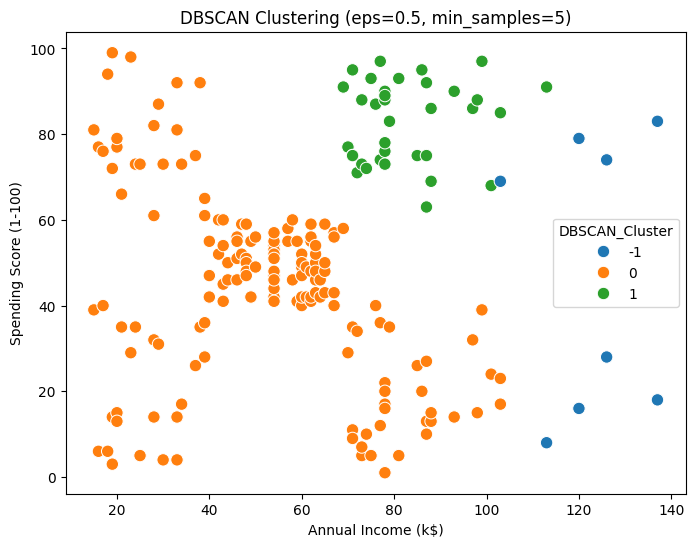

DBSCAN cluster counts:
 0    157
 1     35
-1      8
Name: count, dtype: int64


In [ ]:
db = DBSCAN(eps=0.5, min_samples=5)
db_labels = db.fit_predict(X_scaled)
df['DBSCAN_Cluster'] = db_labels

plt.figure(figsize=(8,6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='DBSCAN_Cluster', data=df, palette='tab10', s=80)
plt.title('DBSCAN Clustering (eps=0.5, min_samples=5)')
plt.show()

print('DBSCAN cluster counts:')
print(pd.Series(db_labels).value_counts())

## 9) Save results
save the dataframe with cluster labels to CSV.

In [ ]:
df.to_csv('Mall_Customers_with_clusters.csv', index=False)
print('Saved Mall_Customers_with_clusters.csv')

Saved Mall_Customers_with_clusters.csv
